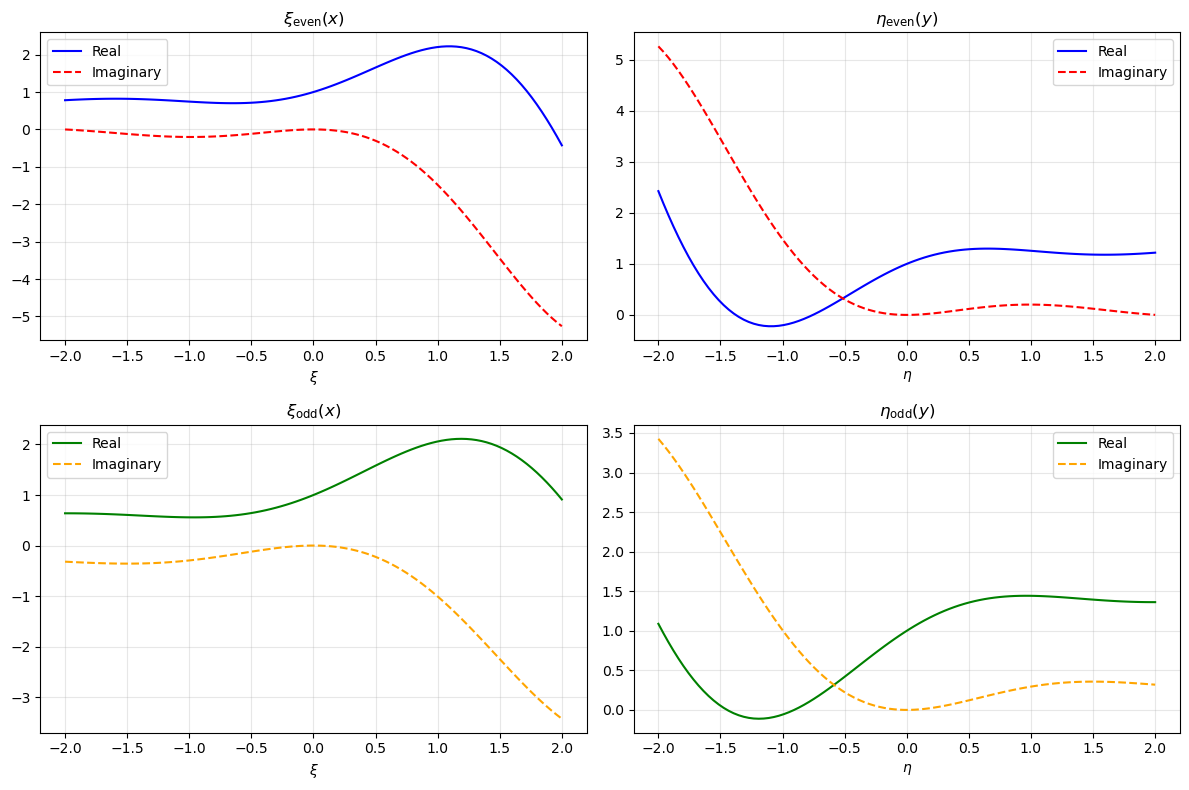

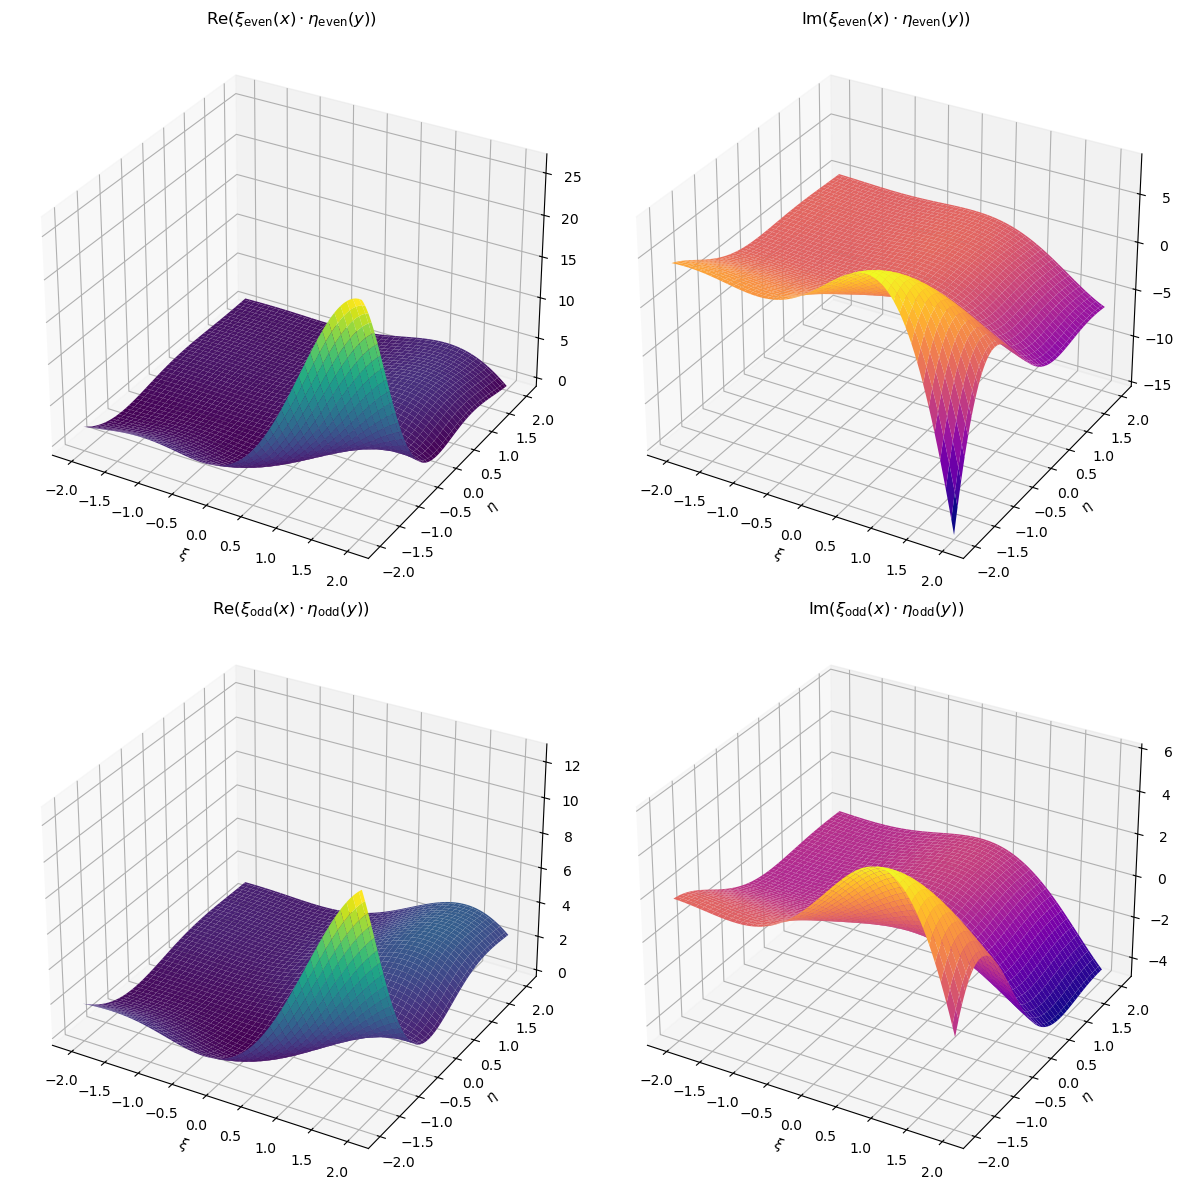

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def even_xi(a, N, n):
    a_val = (4 * n + 1) / 2  
    return -a[N] * (2j * N + 1j/2 - a_val) / ((N + 1) * (N + 0.5))

def even_eta(a, N, n):
    a_val = (4 * n + 1) / 2  
    return -a[N] * (-2j * N - 1j/2 + a_val) / ((N + 1) * (N + 0.5))

def odd_xi(a, N, n):
    a_val = (4 * n + 1) / 2  
    return -a[N] * (2j * N + 3j/2 - a_val) / ((N + 1.5) * (N + 1))

def odd_eta(a, N, n):
    a_val = (4 * n + 1) / 2  
    return -a[N] * (-2j * N - 3j/2 + a_val) / ((N + 1.5) * (N + 1))

max_terms = 50
n = 1
xi = np.linspace(-2, 2, 100)
eta = np.linspace(-2, 2, 100)
XI, ETA = np.meshgrid(xi, eta)

coeffs = {
    'xi_even': np.zeros(max_terms, dtype=complex),
    'eta_even': np.zeros(max_terms, dtype=complex),
    'xi_odd': np.zeros(max_terms, dtype=complex),
    'eta_odd': np.zeros(max_terms, dtype=complex)
}

for key in coeffs:
    coeffs[key][0] = 1
    coeffs[key][1] = 1

for N in range(1, max_terms-1):
    coeffs['xi_even'][N+1] = even_xi(coeffs['xi_even'], N, n)
    coeffs['eta_even'][N+1] = even_eta(coeffs['eta_even'], N, n)
    coeffs['xi_odd'][N+1] = odd_xi(coeffs['xi_odd'], N, n)
    coeffs['eta_odd'][N+1] = odd_eta(coeffs['eta_odd'], N, n)

def f_xi_even(xi):
    return sum(coeffs['xi_even'][s] * xi**s for s in range(max_terms))

def f_eta_even(eta):
    return sum(coeffs['eta_even'][s] * eta**s for s in range(max_terms))

def f_xi_odd(xi):
    return sum(coeffs['xi_odd'][s] * xi**s for s in range(max_terms))

def f_eta_odd(eta):
    return sum(coeffs['eta_odd'][s] * eta**s for s in range(max_terms))

product_even = np.vectorize(lambda x,e: f_xi_even(x) * f_eta_even(e))(XI, ETA)
product_odd = np.vectorize(lambda x,e: f_xi_odd(x) * f_eta_odd(e))(XI, ETA)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(xi, np.real([f_xi_even(x) for x in xi]), label='Real', color='blue')
plt.plot(xi, np.imag([f_xi_even(x) for x in xi]), label='Imaginary', color='red', linestyle='--')
plt.title(r'$\xi_{\text{even}}(x)$')
plt.xlabel(r'$\xi$')
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(eta, np.real([f_eta_even(e) for e in eta]), label='Real', color='blue')
plt.plot(eta, np.imag([f_eta_even(e) for e in eta]), label='Imaginary', color='red', linestyle='--')
plt.title(r'$\eta_{\text{even}}(y)$')
plt.xlabel(r'$\eta$')
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(xi, np.real([f_xi_odd(x) for x in xi]), label='Real', color='green')
plt.plot(xi, np.imag([f_xi_odd(x) for x in xi]), label='Imaginary', color='orange', linestyle='--')
plt.title(r'$\xi_{\text{odd}}(x)$')
plt.xlabel(r'$\xi$')
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(eta, np.real([f_eta_odd(e) for e in eta]), label='Real', color='green')
plt.plot(eta, np.imag([f_eta_odd(e) for e in eta]), label='Imaginary', color='orange', linestyle='--')
plt.title(r'$\eta_{\text{odd}}(y)$')
plt.xlabel(r'$\eta$')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()

fig = plt.figure(figsize=(18, 12))

ax1 = fig.add_subplot(231, projection='3d')
surf1 = ax1.plot_surface(XI, ETA, np.real(product_even), cmap='viridis')
ax1.set_title(r'$\text{Re}(\xi_{\text{even}}(x) \cdot \eta_{\text{even}}(y))$')
ax1.set_xlabel(r'$\xi$')
ax1.set_ylabel(r'$\eta$')

ax2 = fig.add_subplot(232, projection='3d')
surf2 = ax2.plot_surface(XI, ETA, np.imag(product_even), cmap='plasma')
ax2.set_title(r'$\text{Im}(\xi_{\text{even}}(x) \cdot \eta_{\text{even}}(y))$')
ax2.set_xlabel(r'$\xi$')
ax2.set_ylabel(r'$\eta$')

ax3 = fig.add_subplot(234, projection='3d')
surf3 = ax3.plot_surface(XI, ETA, np.real(product_odd), cmap='viridis')
ax3.set_title(r'$\text{Re}(\xi_{\text{odd}}(x) \cdot \eta_{\text{odd}}(y))$')
ax3.set_xlabel(r'$\xi$')
ax3.set_ylabel(r'$\eta$')

ax4 = fig.add_subplot(235, projection='3d')
surf4 = ax4.plot_surface(XI, ETA, np.imag(product_odd), cmap='plasma')
ax4.set_title(r'$\text{Im}(\xi_{\text{odd}}(x) \cdot \eta_{\text{odd}}(y))$')
ax4.set_xlabel(r'$\xi$')
ax4.set_ylabel(r'$\eta$')

plt.tight_layout()
plt.show()

Note: you may need to restart the kernel to use updated packages.
